### Workflow du Projet

Voici les étapes que nous allons suivre :
1.  **Préparation des données** : Chargement de MNIST, normalisation des pixels et encodage des étiquettes.
2.  **Architecture du Modèle** : Création d'un réseau de neurones dense (MLP) avec Keras.
3.  **Entraînement** : Apprentissage sur les données d'entraînement avec suivi de la validation.
4.  **Évaluation & Visualisation** : Analyse de la précision et visualisation des prédictions.

Chargement des données...


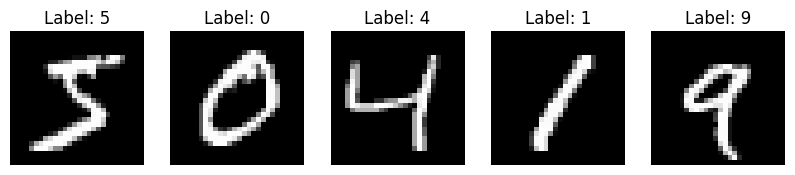

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. Chargement et Prétraitement du Dataset MNIST
# =========================================================

print("Chargement des données...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# --- LA NORMALISATION ---
# Pourquoi ? Les pixels vont de 0 à 255. Les réseaux de neurones
# préfèrent des petites valeurs (0 à 1) pour converger plus vite.
# Quand ? Toujours AVANT de donner les données au modèle.
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# --- L'ENCODAGE ONE-HOT ---
# Quoi ? On transforme un chiffre (ex: 3) en vecteur (ex: [0,0,0,1,0,0,0,0,0,0]).
# Pourquoi ? Pour que le modèle puisse sortir une probabilité par classe
# et ne pas traiter le chiffre comme une valeur mathématique continue.
# Quand ? Juste après le chargement ou via la fonction de perte (Loss).
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Affichage de quelques exemples pour vérification
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [8]:
# =========================================================
# 2. Construction du Réseau de Neurones (Refactorisé)
# =========================================================

model = models.Sequential([
    # Pratique recommandée : Définir l'entrée explicitement avec layers.Input
    layers.Input(shape=(28, 28)),

    # APLATISSAGE : On transforme l'image 2D (28,28) en vecteur 1D (784).
    layers.Flatten(),

    # COUCHE DENSE (Fully Connected) :
    # Qu'est-ce que c'est ? Chaque neurone est connecté à TOUS les pixels d'entrée.
    # Utilité : Apprendre des combinaisons globales de pixels.
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # COUCHE DE SORTIE :
    # 10 neurones (un par chiffre). Softmax donne une probabilité (total = 100%).
    layers.Dense(10, activation='softmax')
])

# --- ALTERNATIVE : POUVAIT-ON UTILISER AUTRE CHOSE ? ---
# OUI ! On utilise souvent des couches CONVOLUTIVES (Conv2D).
# Pourquoi ? Elles sont meilleures pour la vision car elles captent des
# motifs spatiaux (bords, boucles) au lieu de regarder chaque pixel isolément.

# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# =========================================================
# 3. Entraînement du Modèle
# =========================================================

# --- PARAMÈTRES D'ENTRAÎNEMENT ---
# Epochs : Nombre de fois que le modèle voit l'ensemble du dataset.
# Batch Size : Nombre d'images traitées avant de mettre à jour les poids.
# Validation Split : On garde 20% des données pour vérifier si le modèle
# ne fait pas de surapprentissage (overfitting).

print("Début de l'entraînement...")
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Début de l'entraînement...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9203 - loss: 0.2716 - val_accuracy: 0.9600 - val_loss: 0.1381
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9656 - loss: 0.1143 - val_accuracy: 0.9666 - val_loss: 0.1158
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9772 - loss: 0.0770 - val_accuracy: 0.9699 - val_loss: 0.0991
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9820 - loss: 0.0577 - val_accuracy: 0.9742 - val_loss: 0.0925
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9852 - loss: 0.0463 - val_accuracy: 0.9730 - val_loss: 0.0894
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9883 - loss: 0.0348 - val_accuracy: 0.9726 - val_loss: 0.1030
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9904 - loss: 0.0293 - val_accuracy: 0.9737 - val_loss: 0.1035
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accura


Précision finale sur le jeu de test : 0.9751
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


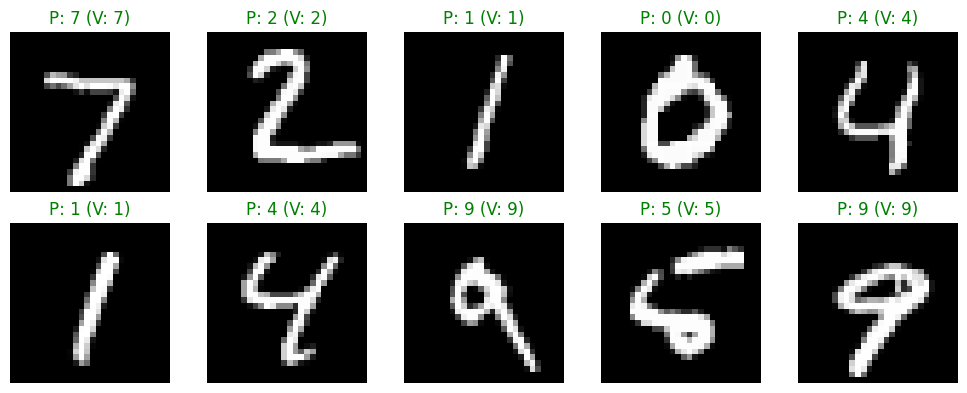

In [10]:
# =========================================================
# 4. Évaluation de la Performance
# =========================================================

# Calcul de la précision sur des données que le modèle n'a JAMAIS vues.
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nPrécision finale sur le jeu de test : {test_acc:.4f}")

# --- VISUALISATION DES PRÉDICTIONS ---
# On demande au modèle de prédire les classes pour le jeu de test.
predictions = model.predict(x_test)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')

    # np.argmax récupère l'indice avec la probabilité la plus élevée
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]

    # Vert si correct, Rouge si erreur
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P: {pred_label} (V: {true_label})", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

###  Analyse Approfondie : Matrice de Confusion
La matrice de confusion permet de voir exactement où le modèle fait des erreurs en croisant les classes réelles et les prédictions.

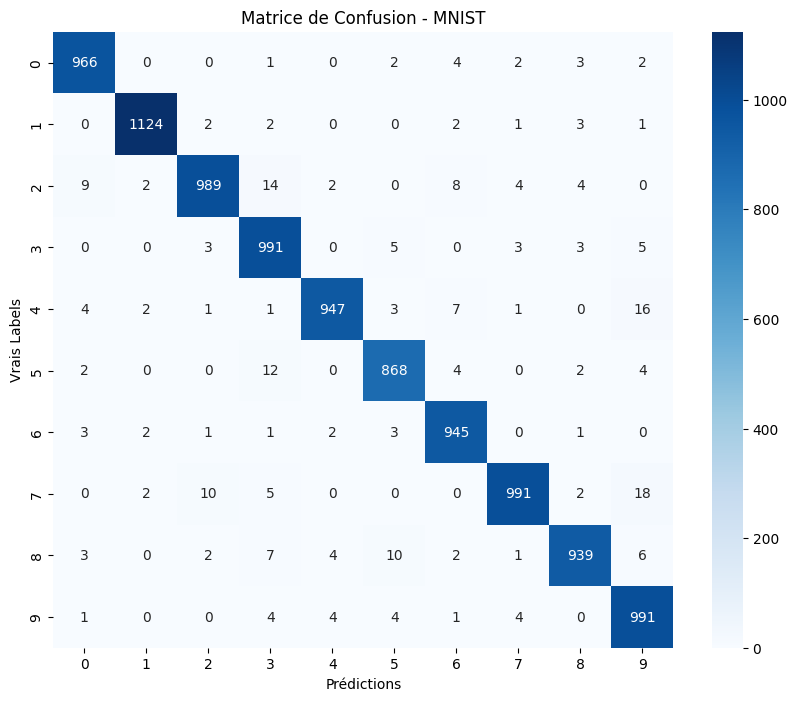

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Conversion des prédictions probas en labels
y_pred_labels = np.argmax(predictions, axis=1)

# Calcul de la matrice
cm = confusion_matrix(y_test, y_pred_labels)

# Visualisation avec Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Prédictions')
plt.ylabel('Vrais Labels')
plt.title('Matrice de Confusion - MNIST')
plt.show()

### Expérience de Hyperparamètres
Comparons l'impact de l'optimiseur sur la performance finale.

In [12]:
def build_model(optimizer='adam'):
    model = models.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

results = {}

for opt in ['adam', 'sgd']:
    print(f"Entraînement avec l'optimiseur : {opt}...")
    temp_model = build_model(opt)
    h = temp_model.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
    results[opt] = h.history['val_accuracy'][-1]
    print(f"Précision de validation finale ({opt}): {results[opt]:.4f}")

print("\nSynthèse du Tuning :", results)

Entraînement avec l'optimiseur : adam...
Précision de validation finale (adam): 0.9713
Entraînement avec l'optimiseur : sgd...
Précision de validation finale (sgd): 0.9190

Synthèse du Tuning : {'adam': 0.9713333249092102, 'sgd': 0.9190000295639038}
